<a href="https://www.kaggle.com/code/lalit7881/healthcare-cybersecurity-eda?scriptVersionId=314478735" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/chuneeb/healthcare-cybersecurity-vulnerabilities-dataset/healthcare_cybersecurity_10k.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/chuneeb/healthcare-cybersecurity-vulnerabilities-dataset/healthcare_cybersecurity_10k.csv")

In [3]:
df.head()

,CVE_ID,Keyword,Published,Last_Modified,Status,Description,Severity,CVSS_Score,Attack_Vector,Weakness,Reference
0,CVE-2011-3386,medical device,2011-09-02,2025-04-11,Deferred,Unspecified vulnerability in Medtronic Paradig...,MEDIUM,4.0,NETWORK,NVD-CWE-noinfo,http://sixuntilme.com/blog2/2011/08/hacked_jay...
1,CVE-2017-12718,medical device,2018-02-15,2024-11-21,Modified,A Classic Buffer Overflow issue was discovered...,MEDIUM,6.8,NETWORK,CWE-120,http://www.securityfocus.com/bid/100665
2,CVE-2017-14002,medical device,2018-03-20,2024-11-21,Modified,GE Infinia/Infinia with Hawkeye 4 medical imag...,HIGH,10.0,NETWORK,CWE-287,http://www.securityfocus.com/bid/103405
3,CVE-2017-14006,medical device,2018-03-20,2024-11-21,Modified,"GE Xeleris versions 1.0,1.1,2.1,3.0,3.1, medic...",HIGH,7.5,NETWORK,CWE-287,https://ics-cert.us-cert.gov/advisories/ICSMA-...
4,CVE-2019-5024,medical device,2019-04-11,2024-11-21,Modified,A restricted environment escape vulnerability ...,HIGH,7.6,PHYSICAL,CWE-693,https://talosintelligence.com/vulnerability_re...


In [4]:
df.tail()

,CVE_ID,Keyword,Published,Last_Modified,Status,Description,Severity,CVSS_Score,Attack_Vector,Weakness,Reference
1510,CVE-2023-32781,HL7,2023-08-09,2024-11-21,Modified,A command injection vulnerability was identifi...,HIGH,7.2,NETWORK,CWE-77,http://packetstormsecurity.com/files/176677/PR...
1511,CVE-2023-28465,HL7,2023-12-12,2025-05-27,Modified,The package-decompression feature in HL7 (Heal...,HIGH,7.5,NETWORK,CWE-22,https://github.com/advisories/GHSA-9654-pr4f-gh6m
1512,CVE-2024-52807,HL7,2025-01-24,2026-04-15,Deferred,The HL7 FHIR IG publisher is a tool to take a ...,HIGH,8.6,NETWORK,CWE-611,https://github.com/HL7/fhir-ig-publisher/commi...
1513,CVE-2025-24363,HL7,2025-01-24,2026-04-15,Deferred,The HL7 FHIR IG publisher is a tool to take a ...,MEDIUM,4.2,LOCAL,CWE-200,https://github.com/HL7/fhir-ig-publisher/commi...
1514,CVE-2025-53948,HL7,2025-08-18,2025-10-17,Analyzed,The Sante PACS Server allows a remote attacker...,HIGH,7.5,NETWORK,CWE-415,https://www.cisa.gov/news-events/ics-medical-a...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1515 entries, 0 to 1514
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CVE_ID         1515 non-null   object 
 1   Keyword        1515 non-null   object 
 2   Published      1515 non-null   object 
 3   Last_Modified  1515 non-null   object 
 4   Status         1515 non-null   object 
 5   Description    1515 non-null   object 
 6   Severity       1497 non-null   object 
 7   CVSS_Score     1497 non-null   float64
 8   Attack_Vector  1497 non-null   object 
 9   Weakness       1514 non-null   object 
 10  Reference      1515 non-null   object 
dtypes: float64(1), object(10)
memory usage: 130.3+ KB


In [6]:
df.describe()

,CVSS_Score
count,1497.000000
mean,6.554108
std,1.956064
min,1.900000
25%,5.400000
50%,6.500000
75%,7.600000
max,10.000000


In [7]:
df.isnull().sum()

CVE_ID            0
Keyword           0
Published         0
Last_Modified     0
Status            0
Description       0
Severity         18
CVSS_Score       18
Attack_Vector    18
Weakness          1
Reference         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

CVE_ID            object
Keyword           object
Published         object
Last_Modified     object
Status            object
Description       object
Severity          object
CVSS_Score       float64
Attack_Vector     object
Weakness          object
Reference         object
dtype: object

In [10]:
df.shape

(1515, 11)

In [11]:
df.columns

Index(['CVE_ID', 'Keyword', 'Published', 'Last_Modified', 'Status',
       'Description', 'Severity', 'CVSS_Score', 'Attack_Vector', 'Weakness',
       'Reference'],
      dtype='object')

In [12]:
df.nunique()

CVE_ID           1515
Keyword            20
Published         602
Last_Modified     203
Status              5
Description      1493
Severity            4
CVSS_Score         68
Attack_Vector       4
Weakness          144
Reference        1007
dtype: int64

## EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1515 entries, 0 to 1514
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CVE_ID         1515 non-null   object        
 1   Keyword        1515 non-null   object        
 2   Published      1515 non-null   datetime64[ns]
 3   Last_Modified  1515 non-null   datetime64[ns]
 4   Status         1515 non-null   object        
 5   Description    1515 non-null   object        
 6   Severity       1497 non-null   object        
 7   CVSS_Score     1497 non-null   float64       
 8   Attack_Vector  1497 non-null   object        
 9   Weakness       1514 non-null   object        
 10  Reference      1515 non-null   object        
dtypes: datetime64[ns](2), float64(1), object(8)
memory usage: 130.3+ KB
None
                           Published                  Last_Modified  \
count                           1515                           1515   
mean   202

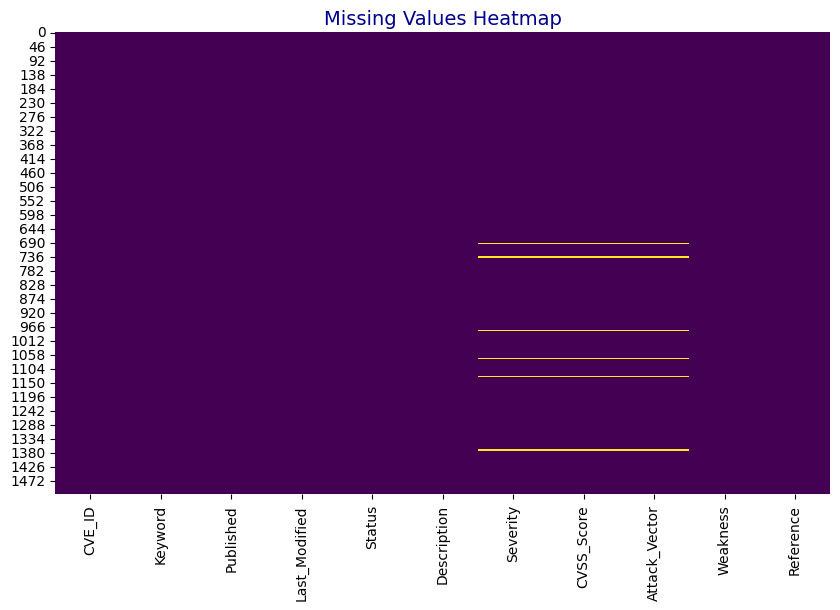

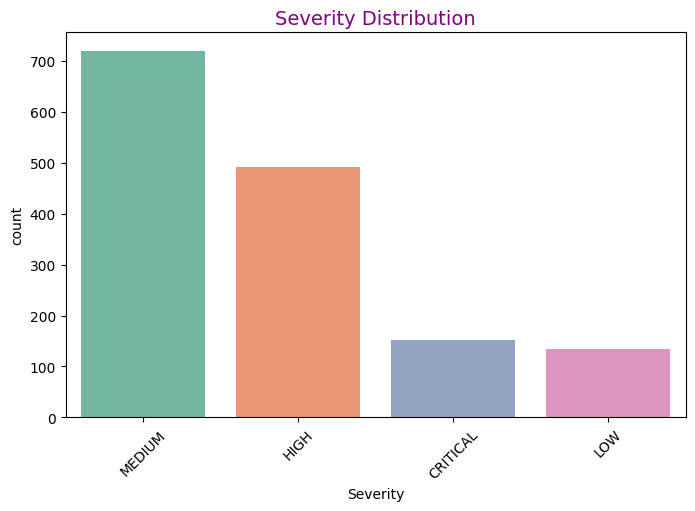

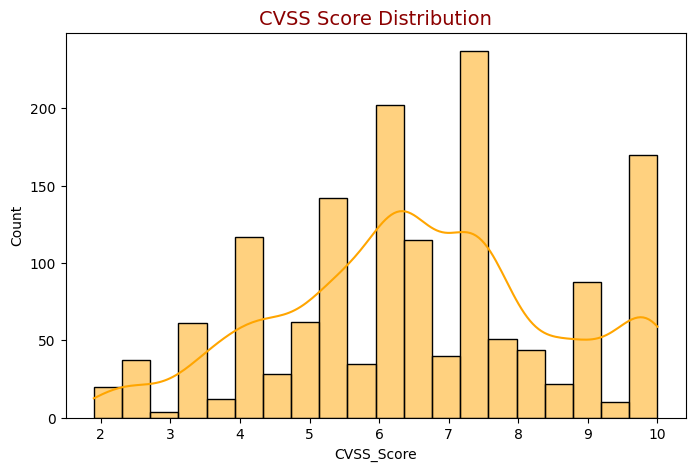

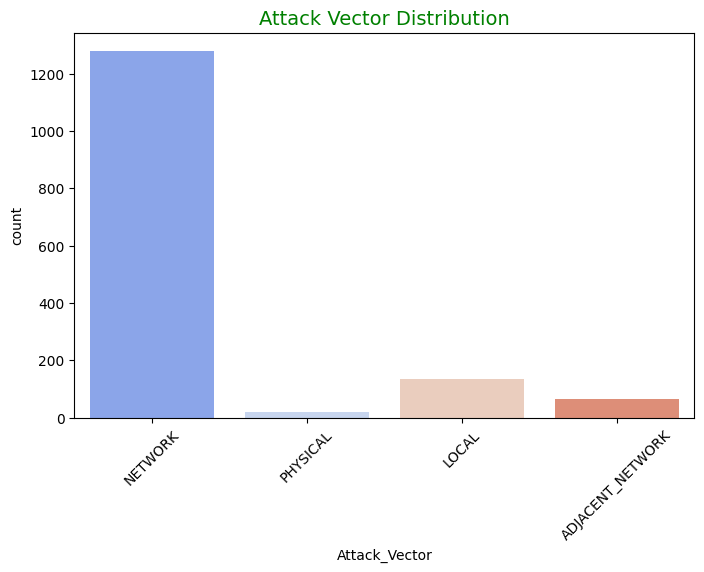

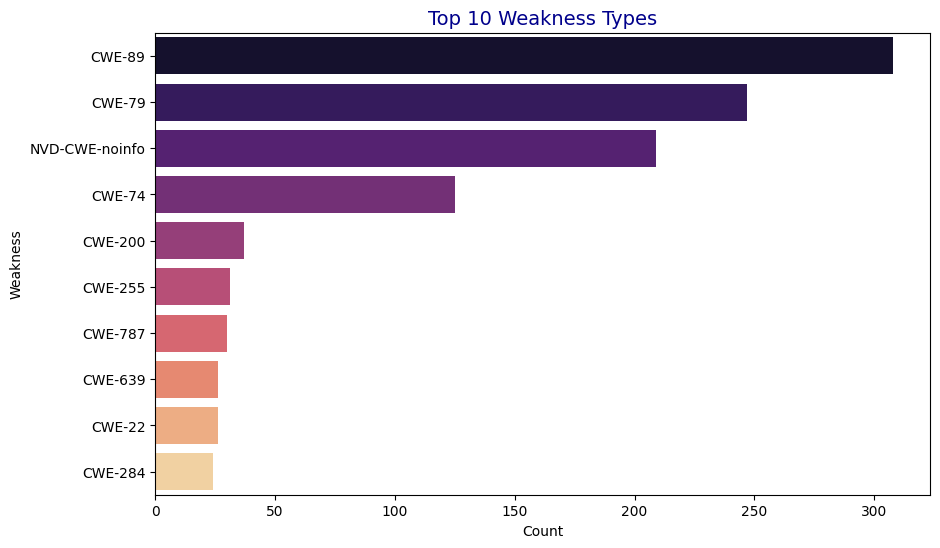

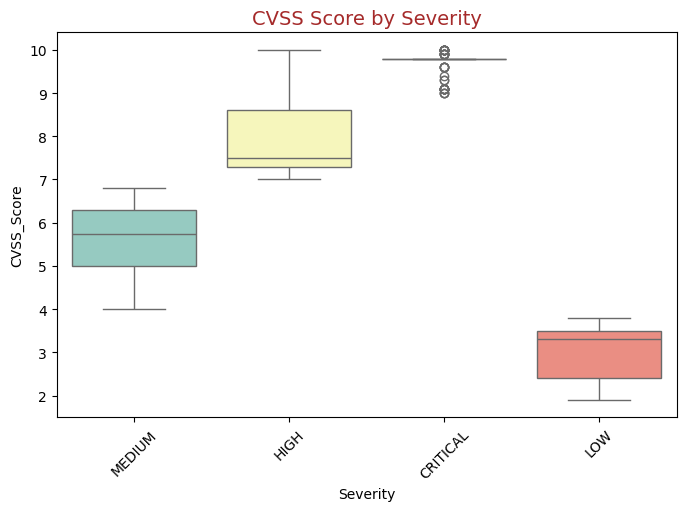

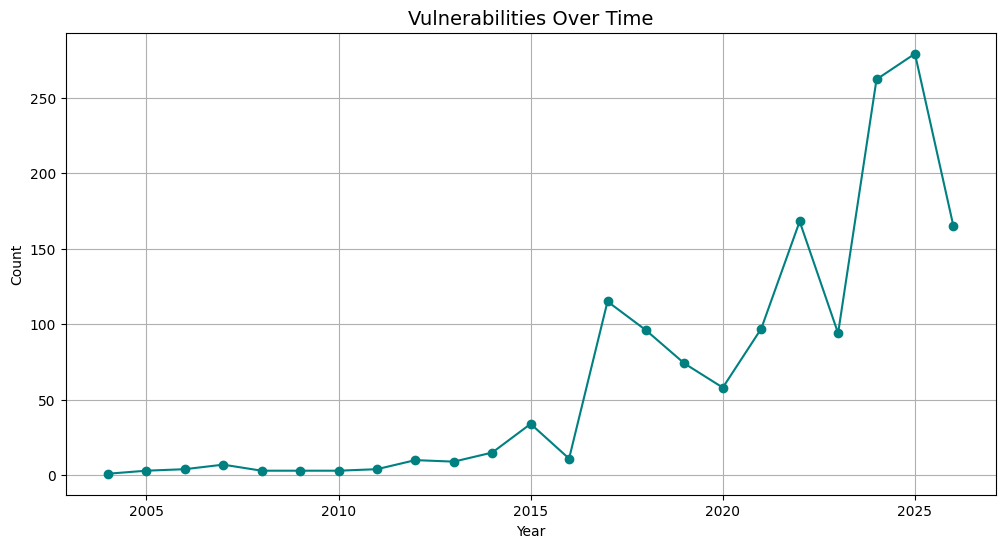

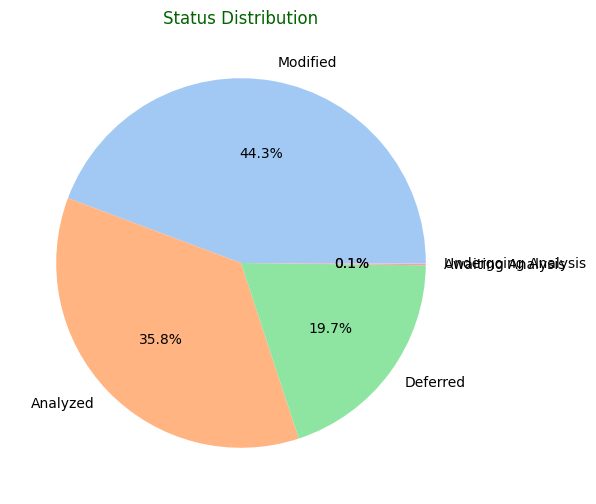

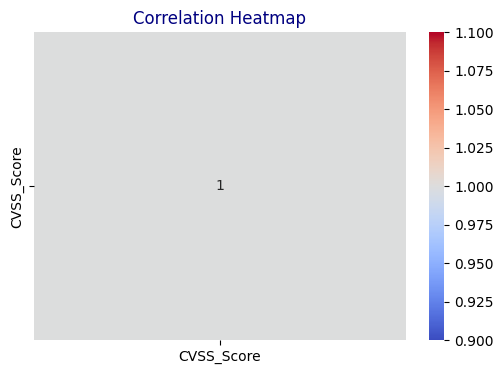

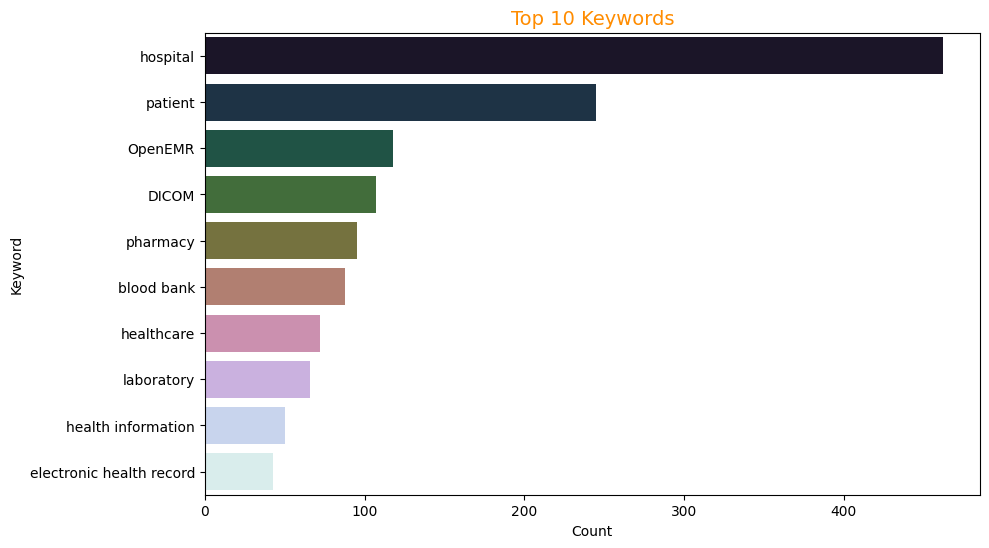

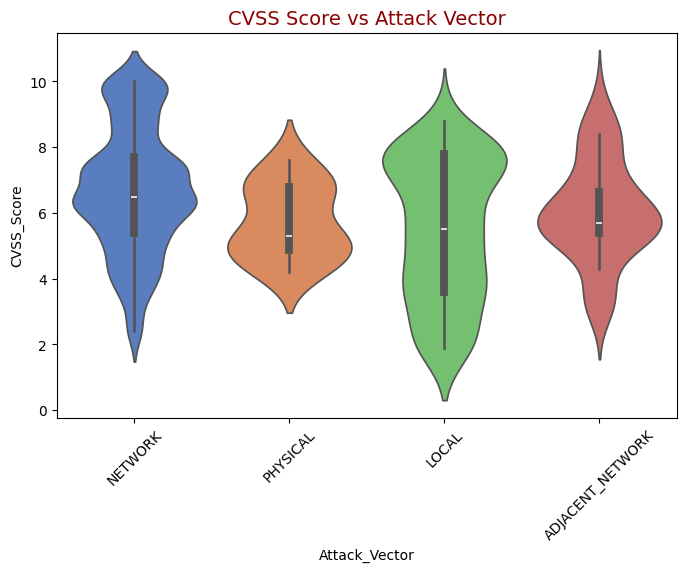

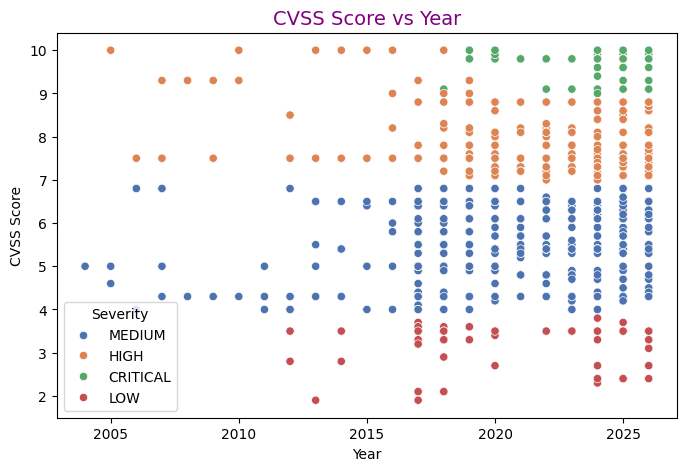

In [13]:
# Convert date columns
df['Published'] = pd.to_datetime(df['Published'], errors='coerce')
df['Last_Modified'] = pd.to_datetime(df['Last_Modified'], errors='coerce')

# =========================
# 3. Basic Info
# =========================
print(df.info())
print(df.describe())

# =========================
# 4. Missing Values Heatmap
# =========================
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap", color='darkblue', fontsize=14)
plt.show()

# =========================
# 5. Severity Count Plot
# =========================
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Severity', palette='Set2')
plt.title("Severity Distribution", color='purple', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# =========================
# 6. CVSS Score Distribution
# =========================
plt.figure(figsize=(8,5))
sns.histplot(df['CVSS_Score'], bins=20, kde=True, color='orange')
plt.title("CVSS Score Distribution", color='darkred', fontsize=14)
plt.show()

# =========================
# 7. Attack Vector Distribution
# =========================
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Attack_Vector', palette='coolwarm')
plt.title("Attack Vector Distribution", color='green', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# =========================
# 8. Top 10 Weakness Types
# =========================
plt.figure(figsize=(10,6))
top_weakness = df['Weakness'].value_counts().head(10)
sns.barplot(x=top_weakness.values, y=top_weakness.index, palette='magma')
plt.title("Top 10 Weakness Types", color='darkblue', fontsize=14)
plt.xlabel("Count")
plt.ylabel("Weakness")
plt.show()

# =========================
# 9. CVSS Score by Severity
# =========================
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Severity', y='CVSS_Score', palette='Set3')
plt.title("CVSS Score by Severity", color='brown', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# =========================
# 10. Timeline of Vulnerabilities
# =========================
plt.figure(figsize=(12,6))
df['Published'].dt.year.value_counts().sort_index().plot(
    kind='line', marker='o', color='teal'
)
plt.title("Vulnerabilities Over Time", color='black', fontsize=14)
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# =========================
# 11. Status Distribution (Pie Chart)
# =========================
plt.figure(figsize=(6,6))
df['Status'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel')
)
plt.title("Status Distribution", color='darkgreen')
plt.ylabel("")
plt.show()

# =========================
# 12. Correlation Heatmap
# =========================
plt.figure(figsize=(6,4))
corr = df[['CVSS_Score']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap", color='navy')
plt.show()

# =========================
# 13. Keyword Frequency (Top 10)
# =========================
plt.figure(figsize=(10,6))
top_keywords = df['Keyword'].value_counts().head(10)
sns.barplot(x=top_keywords.values, y=top_keywords.index, palette='cubehelix')
plt.title("Top 10 Keywords", color='darkorange', fontsize=14)
plt.xlabel("Count")
plt.ylabel("Keyword")
plt.show()

# =========================
# 14. CVSS Score vs Attack Vector
# =========================
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='Attack_Vector', y='CVSS_Score', palette='muted')
plt.title("CVSS Score vs Attack Vector", color='darkred', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# =========================
# 15. Scatter Plot CVSS vs Published Year
# =========================
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['Published'].dt.year,
    y=df['CVSS_Score'],
    hue=df['Severity'],
    palette='deep'
)
plt.title("CVSS Score vs Year", color='purple', fontsize=14)
plt.xlabel("Year")
plt.ylabel("CVSS Score")
plt.show()

## Feature engineering


Logistic Regression
Accuracy: 0.9504950495049505
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        30
           1       0.96      0.98      0.97        98
           2       0.92      0.89      0.91        27
           3       0.95      0.99      0.97       144
           4       0.00      0.00      0.00         4

    accuracy                           0.95       303
   macro avg       0.75      0.74      0.75       303
weighted avg       0.94      0.95      0.94       303


Decision Tree
Accuracy: 0.9900990099009901
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        30
           1       0.98      0.99      0.98        98
           2       1.00      1.00      1.00        27
           3       1.00      1.00      1.00       144
           4       1.00      1.00      1.00         4

    accuracy                           0.99       303
   macro avg       0.99      0.98    

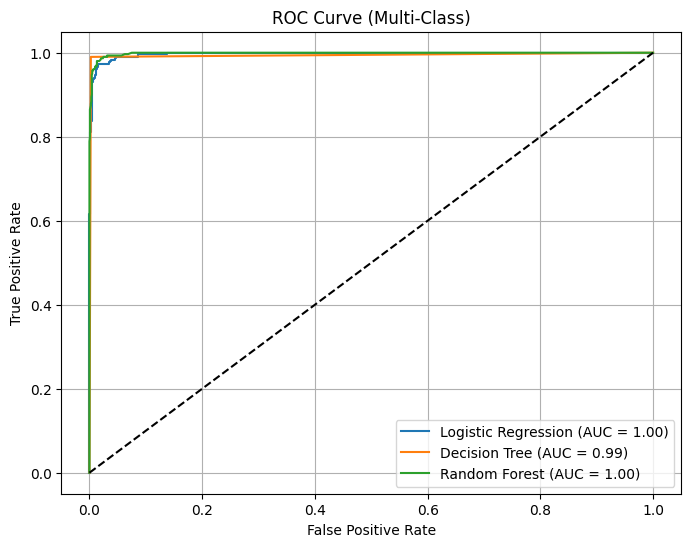

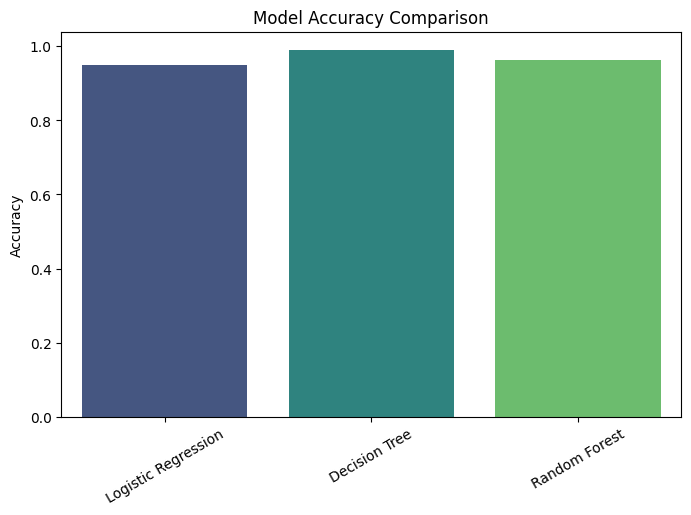

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# =========================
# 3. Preprocessing
# =========================

# Convert dates
df['Published'] = pd.to_datetime(df['Published'], errors='coerce')
df['Last_Modified'] = pd.to_datetime(df['Last_Modified'], errors='coerce')

# Extract useful features from date
df['Published_Year'] = df['Published'].dt.year
df['Published_Month'] = df['Published'].dt.month

# Drop raw date columns (avoid leakage / unnecessary complexity)
df.drop(['Published', 'Last_Modified', 'CVE_ID', 'Description', 'Reference'], axis=1, inplace=True)

# =========================
# 4. Define Target & Features
# =========================
target = 'Severity'
X = df.drop(target, axis=1)
y = df[target]

# Encode target separately (safe)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# =========================
# 5. Train-Test Split (BEFORE encoding)
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 6. Column Separation
# =========================
num_cols = ['CVSS_Score', 'Published_Year', 'Published_Month']
cat_cols = [col for col in X.columns if col not in num_cols]

# =========================
# 7. Preprocessing Pipelines (NO LEAKAGE)
# =========================

# Numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# =========================
# 8. Models
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

# =========================
# 9. Training + Evaluation
# =========================
results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipe.fit(X_train, y_train)
    
    # Predict
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

# =========================
# 10. ROC Curve (Multi-class)
# =========================

# Binarize labels for ROC
n_classes = len(np.unique(y))
y_test_bin = label_binarize(y_test, classes=range(n_classes))

plt.figure(figsize=(8,6))

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)
    
    # Compute ROC for each class
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot formatting
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-Class)")
plt.legend()
plt.grid()
plt.show()

# =========================
# 11. Model Accuracy Comparison
# =========================
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

## Thank you..pls upvote!!!!!!!!!!!